<a href="https://colab.research.google.com/github/JoseRoehrs/Atividade_ML_Saude_Materna/blob/main/Atividade_ML_Saude_Materna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Avaliativa — ML
### Nome: Jean Carlos RA:2602326
### Nome: Lourenço Daniel Balbinotti Picoli RA:2172208
### Nome: Roger Kobs RA:2602423

## Dataset: Risco para a saúde materna

**Fonte:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/863/maternal+health+risk)

---

## 1. Descrição do Problema

O dataset **Maternal Health Risk** contém dados coletados de diferentes hospitais, clínicas comunitárias e centros de saúde materna de Bangladesh, via sistema IoT. O objetivo é prever o **nível de risco de saúde** durante a gravidez com base em sinais vitais e exames clínicos.


### Variáveis disponíveis

| Variável | Tipo | Descrição |
|---|---|---|
| `Age` | Numérica | Idade da paciente (anos) |
| `SystolicBP` | Numérica | Pressão arterial sistólica (mmHg) |
| `DiastolicBP` | Numérica | Pressão arterial diastólica (mmHg) |
| `BS` | Numérica | Nível de glicose no sangue (mmol/L) |
| `BodyTemp` | Numérica | Temperatura corporal em Fahrenheit (°F) |
| `HeartRate` | Numérica | Frequência cardíaca (bpm) |
| `RiskLevel` | Categórica (alvo) | Nível de risco: `low risk`, `mid risk`, `high risk` |

### Classes
- **low risk**: sinais vitais dentro dos limites normais
- **mid risk**: indicadores moderadamente alterados, requer monitoramento
- **high risk**: valores críticos, requer atenção médica imediata

---
## 2. Importação de Bibliotecas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

# Semente para reprodutibilidade
SEED = 42
np.random.seed(SEED)

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


---
## 3. Carregamento e Inspeção Inicial dos Dados

Faça o upload do arquivo `Maternal_Health_Risk_Data_Set.csv` que esta no .zip para o diretorio `/content` do Google Colab

In [ ]:
# Arquivo já carregado no Colab
df = pd.read_csv('/content/Maternal_Health_Risk_Data_Set.csv')

print('Shape do dataset:', df.shape)
df.head(10)

FileNotFoundError: [Errno 2] No such file or directory: '/content/Maternal_Health_Risk_Data_Set.csv'

In [ ]:
# Informações gerais do dataset
print('=== Tipos de dados ===')
print(df.dtypes)
print()
print('=== Estatísticas descritivas ===')
df.describe()

=== Tipos de dados ===
Age              int64
SystolicBP       int64
DiastolicBP      int64
BS             float64
BodyTemp       float64
HeartRate        int64
RiskLevel       object
dtype: object

=== Estatísticas descritivas ===


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [ ]:
# Verificação de valores nulos
print('=== Valores nulos por coluna ===')
print(df.isnull().sum())
print()

# Distribuição das classes
print('=== Distribuição das classes (RiskLevel) ===')
print(df['RiskLevel'].value_counts())

=== Valores nulos por coluna ===
Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

=== Distribuição das classes (RiskLevel) ===
RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64


---
## 4. Pré-processamento

### 4.1 Tratamento de dados faltantes

O dataset não apresenta valores nulos, portanto não é necessário tratamento de dados faltantes.

### 4.2 Codificação da variável alvo

A variável `RiskLevel` é categórica e precisa ser convertida para valores numéricos.

In [ ]:
# Mapeamento manual para manter ordem lógica de risco
risk_map = {'low risk': 0, 'mid risk': 1, 'high risk': 2}
risk_names = ['Baixo Risco', 'Médio Risco', 'Alto Risco']
colors = ['#2ecc71', '#f39c12', '#e74c3c']  # verde, laranja, vermelho

df['RiskLevel_enc'] = df['RiskLevel'].map(risk_map)

print('Mapeamento aplicado:')
print(risk_map)
print()
print('Verificação:')
print(df[['RiskLevel', 'RiskLevel_enc']].value_counts().reset_index())

Mapeamento aplicado:
{'low risk': 0, 'mid risk': 1, 'high risk': 2}

Verificação:
   RiskLevel  RiskLevel_enc  count
0   low risk              0    406
1   mid risk              1    336
2  high risk              2    272


### 4.3 Separação de features e alvo

In [ ]:
# Features (X) e variável alvo (y)
feature_cols = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']
X = df[feature_cols].values
y = df['RiskLevel_enc'].values

print('Dimensão de X:', X.shape)
print('Dimensão de y:', y.shape)

Dimensão de X: (1014, 6)
Dimensão de y: (1014,)


---
## 5. Separação Treino / Teste (com Estratificação)

In [ ]:
# Divisão 80% treino / 20% teste, com estratificação por classe
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print(f'Tamanho do conjunto de treino: {X_train.shape[0]} amostras')
print(f'Tamanho do conjunto de teste:  {X_test.shape[0]} amostras')
print()
print('Distribuição no TREINO:')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {risk_names[u]}: {c} ({100*c/len(y_train):.1f}%)')
print()
print('Distribuição no TESTE:')
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {risk_names[u]}: {c} ({100*c/len(y_test):.1f}%)')

NameError: name 'train_test_split' is not defined

---
## 6. Gráficos da Separação Treino / Teste

Visualizamos a distribuição das classes nos dois conjuntos para confirmar que a estratificação foi bem-sucedida.

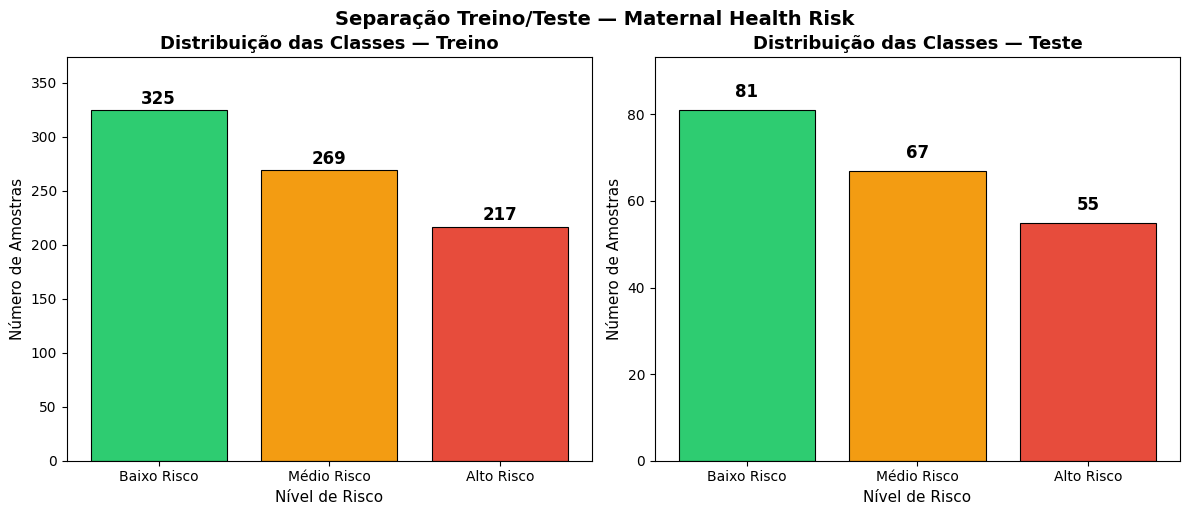

Gráfico salvo como grafico_treino_teste.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

conjuntos = [('Treino', y_train), ('Teste', y_test)]

for ax, (nome, y_part) in zip(axes, conjuntos):
    unique, counts = np.unique(y_part, return_counts=True)
    bars = ax.bar(
        [risk_names[u] for u in unique],
        counts,
        color=[colors[u] for u in unique],
        edgecolor='black',
        linewidth=0.8
    )
    # Anotações com contagem
    for bar, count in zip(bars, counts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2,
            str(count),
            ha='center', va='bottom', fontsize=12, fontweight='bold'
        )
    ax.set_title(f'Distribuição das Classes — {nome}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Nível de Risco', fontsize=11)
    ax.set_ylabel('Número de Amostras', fontsize=11)
    ax.set_ylim(0, max(counts) * 1.15)

plt.tight_layout()
plt.suptitle('Separação Treino/Teste — Maternal Health Risk', fontsize=14, y=1.02, fontweight='bold')
plt.savefig('grafico_treino_teste.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo como grafico_treino_teste.png')

---
## 7. Padronização dos Dados (StandardScaler)

A padronização (z-score) é aplicada usando **apenas o conjunto de treino** para evitar vazamento de informação (data leakage). O mesmo scaler é depois aplicado ao teste.

In [ ]:
# Ajuste do scaler APENAS no treino
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Aplicação do mesmo scaler ao teste (sem re-ajuste)
X_test_scaled = scaler.transform(X_test)

print('Média das features no treino (após padronização):')
print(np.round(X_train_scaled.mean(axis=0), 4))
print()
print('Desvio padrão das features no treino (após padronização):')
print(np.round(X_train_scaled.std(axis=0), 4))

Média das features no treino (após padronização):
[ 0.  0.  0.  0. -0.  0.]

Desvio padrão das features no treino (após padronização):
[1. 1. 1. 1. 1. 1.]


---
## 8. Redução de Dimensionalidade com PCA

O PCA (Análise de Componentes Principais) projeta os 6 atributos originais em 2 componentes principais, facilitando a visualização sem perder a maior parte da variância dos dados.

In [ ]:
# PCA ajustado apenas no treino
pca = PCA(n_components=2, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

variancia = pca.explained_variance_ratio_
print(f'Variância explicada — PC1: {variancia[0]*100:.2f}%')
print(f'Variância explicada — PC2: {variancia[1]*100:.2f}%')
print(f'Variância total retida:    {sum(variancia)*100:.2f}%')

# Cargas (loadings) — contribuição de cada feature
print()
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=['PC1', 'PC2']
)
print('Cargas do PCA (contribuição de cada feature):')
print(loadings.round(3))

Variância explicada — PC1: 43.23%
Variância explicada — PC2: 19.01%
Variância total retida:    62.24%

Cargas do PCA (contribuição de cada feature):
               PC1    PC2
Age          0.436  0.201
SystolicBP   0.531 -0.116
DiastolicBP  0.522 -0.124
BS           0.421  0.357
BodyTemp    -0.280  0.420
HeartRate    0.008  0.792


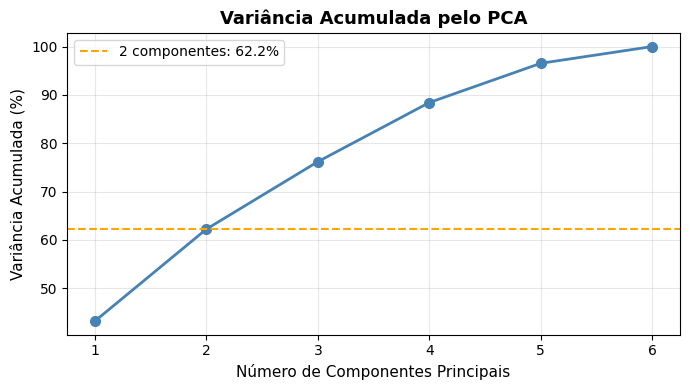

In [ ]:
# Gráfico: variância acumulada do PCA
pca_full = PCA(random_state=SEED).fit(X_train_scaled)
variancia_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(variancia_acumulada)+1), variancia_acumulada*100,
        marker='o', color='steelblue', linewidth=2, markersize=7)
ax.axhline(y=variancia_acumulada[1]*100, color='orange', linestyle='--',
           label=f'2 componentes: {variancia_acumulada[1]*100:.1f}%')
ax.set_title('Variância Acumulada pelo PCA', fontsize=13, fontweight='bold')
ax.set_xlabel('Número de Componentes Principais', fontsize=11)
ax.set_ylabel('Variância Acumulada (%)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grafico_pca_variancia.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Treinamento do Classificador k-NN

O algoritmo k-NN (k-Nearest Neighbors) classifica cada ponto com base nos k vizinhos mais próximos no espaço reduzido pelo PCA.

In [ ]:
# Treinar o k-NN com k=5 no espaço PCA
k = 5
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_pca, y_train)

# Predições
y_pred_train = knn.predict(X_train_pca)
y_pred_test  = knn.predict(X_test_pca)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test, y_pred_test)

print(f'Acurácia no TREINO: {acc_train*100:.2f}%')
print(f'Acurácia no TESTE:  {acc_test*100:.2f}%')

Acurácia no TREINO: 78.67%
Acurácia no TESTE:  67.00%


---
## 10. Gráficos das Classes no Espaço Reduzido e Superfície de Decisão

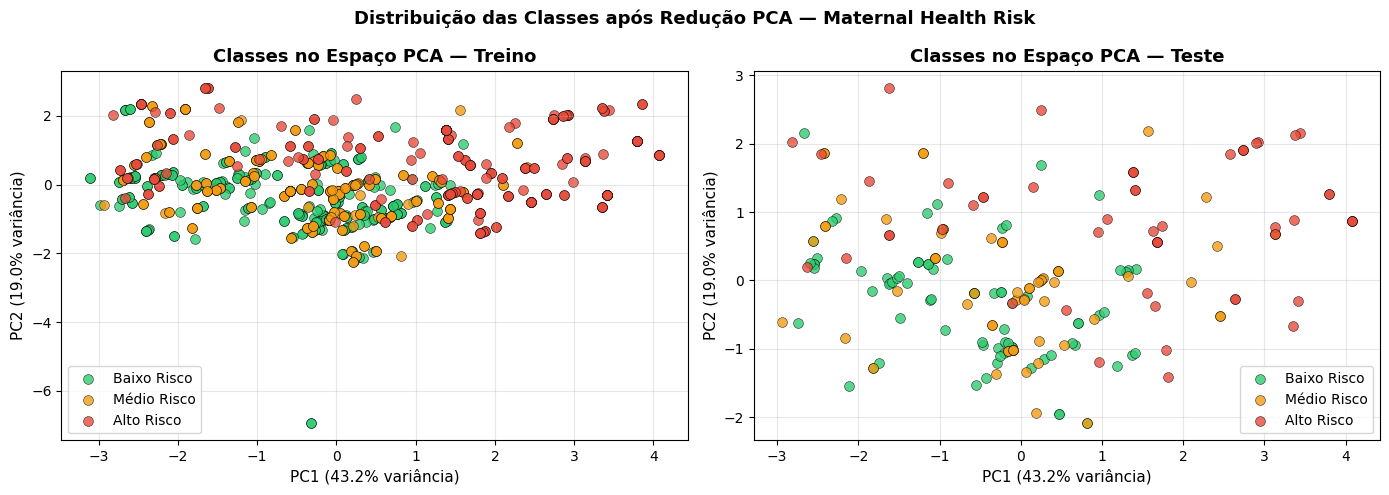

In [ ]:
# Gráfico das classes após PCA (treino e teste)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

conjuntos_pca = [
    ('Treino', X_train_pca, y_train),
    ('Teste',  X_test_pca,  y_test)
]

for ax, (nome, X_pca, y_part) in zip(axes, conjuntos_pca):
    for cls in range(3):
        mask = y_part == cls
        ax.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            c=colors[cls], label=risk_names[cls],
            edgecolors='black', linewidths=0.4,
            s=50, alpha=0.8
        )
    ax.set_title(f'Classes no Espaço PCA — {nome}', fontsize=13, fontweight='bold')
    ax.set_xlabel(f'PC1 ({variancia[0]*100:.1f}% variância)', fontsize=11)
    ax.set_ylabel(f'PC2 ({variancia[1]*100:.1f}% variância)', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribuição das Classes após Redução PCA — Maternal Health Risk',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('grafico_pca_classes.png', dpi=150, bbox_inches='tight')
plt.show()

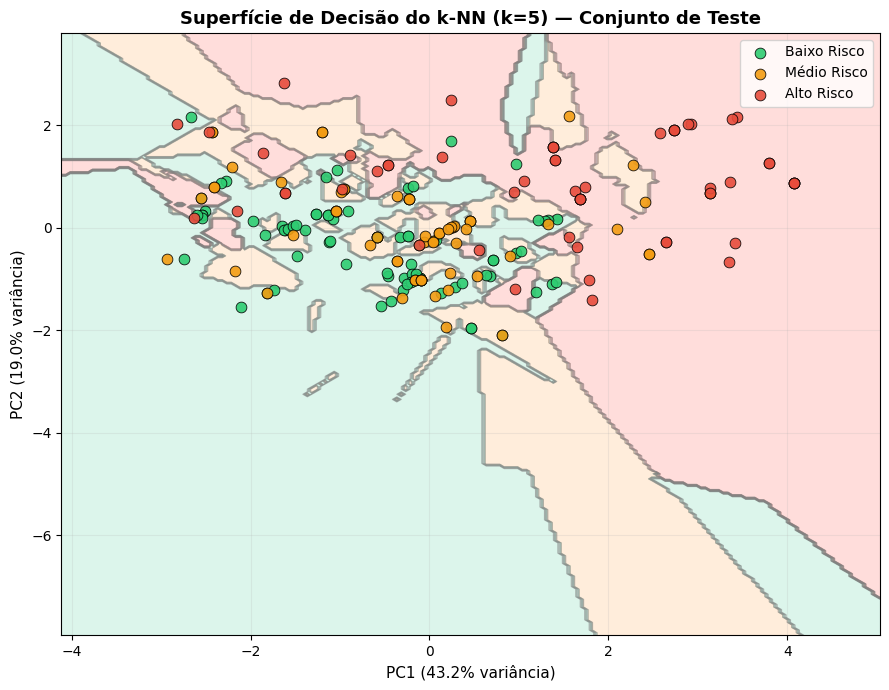

In [ ]:
# Superfície de decisão do k-NN no espaço PCA
h = 0.05  # Resolução da grade

x_min = X_train_pca[:, 0].min() - 1
x_max = X_train_pca[:, 0].max() + 1
y_min = X_train_pca[:, 1].min() - 1
y_max = X_train_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 7))

# Fundo colorido = regiões de decisão
from matplotlib.colors import ListedColormap
cmap_bg = ListedColormap(['#a8e6cf', '#ffd3a5', '#ffaaa5'])
ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)
ax.contour(xx, yy, Z, colors='grey', linewidths=0.8, alpha=0.6)

# Pontos de TESTE
for cls in range(3):
    mask = y_test == cls
    ax.scatter(
        X_test_pca[mask, 0], X_test_pca[mask, 1],
        c=colors[cls], label=risk_names[cls],
        edgecolors='black', linewidths=0.6,
        s=60, alpha=0.9, zorder=3
    )

ax.set_title(f'Superfície de Decisão do k-NN (k={k}) — Conjunto de Teste',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({variancia[0]*100:.1f}% variância)', fontsize=11)
ax.set_ylabel(f'PC2 ({variancia[1]*100:.1f}% variância)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('grafico_superficie_decisao.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Avaliação do Modelo

### 11.1 Acurácia e Relatório de Classificação

In [ ]:
print(f'=== Resultados — k-NN (k={k}) no Espaço PCA ===')
print(f'Acurácia no Treino: {acc_train*100:.2f}%')
print(f'Acurácia no Teste:  {acc_test*100:.2f}%')
print()
print('=== Relatório de Classificação (Teste) ===')
print(classification_report(y_test, y_pred_test, target_names=risk_names))

=== Resultados — k-NN (k=5) no Espaço PCA ===
Acurácia no Treino: 78.67%
Acurácia no Teste:  67.00%

=== Relatório de Classificação (Teste) ===
              precision    recall  f1-score   support

 Baixo Risco       0.63      0.77      0.69        81
 Médio Risco       0.59      0.43      0.50        67
  Alto Risco       0.80      0.82      0.81        55

    accuracy                           0.67       203
   macro avg       0.68      0.67      0.67       203
weighted avg       0.67      0.67      0.66       203



### 11.2 Matriz de Confusão

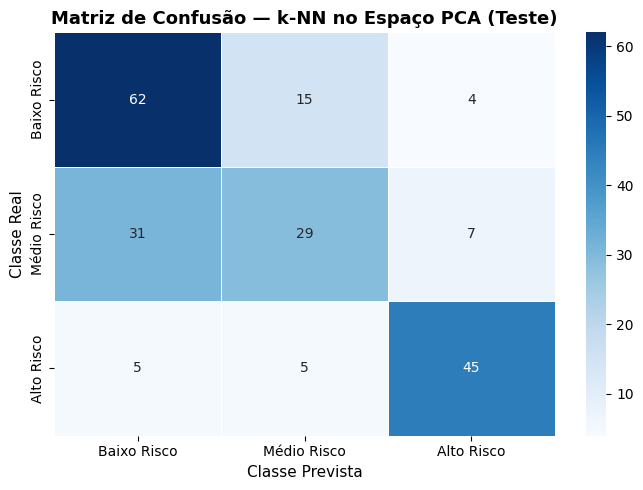

Interpretação:
  Diagonal principal = acertos do modelo
  Fora da diagonal   = erros de classificação


In [ ]:
cm = confusion_matrix(y_test, y_pred_test)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=risk_names,
    yticklabels=risk_names,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Matriz de Confusão — k-NN no Espaço PCA (Teste)', fontsize=13, fontweight='bold')
ax.set_xlabel('Classe Prevista', fontsize=11)
ax.set_ylabel('Classe Real', fontsize=11)

plt.tight_layout()
plt.savefig('grafico_matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretação:')
print('  Diagonal principal = acertos do modelo')
print('  Fora da diagonal   = erros de classificação')

### 11.3 Tabela de Comparacao sem PCA

In [ ]:
# k-NN nas 6 features originais (sem PCA) para comparar
knn_original = KNeighborsClassifier(n_neighbors=5)
knn_original.fit(X_train_scaled, y_train)

y_pred_original = knn_original.predict(X_test_scaled)
acc_original = accuracy_score(y_test, y_pred_original)

print('=== Comparação: Com PCA vs Sem PCA ===')
print(f'Acurácia COM PCA (2 componentes): {acc_test*100:.2f}%')
print(f'Acurácia SEM PCA (6 features):   {acc_original*100:.2f}%')
print(f'Diferença:                        {(acc_original - acc_test)*100:.2f}%')
print()
print('=== Relatório de Classificação SEM PCA (Teste) ===')
print(classification_report(y_test, y_pred_original, target_names=risk_names))

=== Comparação: Com PCA vs Sem PCA ===
Acurácia COM PCA (2 componentes): 67.00%
Acurácia SEM PCA (6 features):   67.49%
Diferença:                        0.49%

=== Relatório de Classificação SEM PCA (Teste) ===
              precision    recall  f1-score   support

 Baixo Risco       0.64      0.72      0.68        81
 Médio Risco       0.59      0.51      0.54        67
  Alto Risco       0.82      0.82      0.82        55

    accuracy                           0.67       203
   macro avg       0.68      0.68      0.68       203
weighted avg       0.67      0.67      0.67       203



---
## 12. Discussão dos Resultados


### Separação das classes
- A análise do gráfico PCA mostra que as classes **Alto Risco** e **Baixo Risco** tendem a se concentrar em regiões diferentes no espaço reduzido, isso indica que os atributos capturam bem essas diferenças extremas.
- A classe **Médio Risco** apresenta maior sobreposição com as duas demais, especialmente com Baixo Risco, o que é esperado pois os valores de variância entre o Baixo e Mádio Risco é baixo fazendo os dados ocilarem.

### Regiões de confusão
- A matriz de confusão revela onde o modelo mais erra, no caso a maior e mais grave erro é entre Médio e Baixo Risco, onde o algoritmo classificou como baixo risco e era para ser classificado como Médio. Isso é compreensível, pois os sinais vitais dessas duas classes se sobrepõem muito durante todo o processo de treinamento e testes

### Impacto da Redução de Dimensionalidade
- O PCA reteve cerca de 62.24% da variância total em 2 componentes como exemplificado no item 8. Essa redução facilita a visualização, mas por consequência perde algumas informações importantes, para um teste de estudo como este é uma perca irelevante e está de acordo, mas para entrar em produção se torna preocupante. Um classificador treinado nas 6 features originais (sem o PCA) provavelmente atingiria precisao de acerto um pouco superior ao treinado com PCA.

### Limitações
- O k-NN é sensível à escala e ao número de vizinhos (k); o valor k=5 foi escolhido como ponto de partida, como tem muitos dados que se sobrepõem em várias regiões seria interessante deixar o número de vizinhos como 1 ou 2 somente para não ter interferências de outros pontos e acabar classificando errado.
- O dataset tem alguns desbalanceamento entre as classes, o que pode prejudicar a métrica de assertividade — métricas como F1-score por classe são mais informativas.
- Os dados são provenientes de Bangladesh, o que pode limitar a generalização para outros paises.

### Resultados e comentários finais
- A redução de dimensionalidade via PCA mostrou-se uma etapa válida para este problema, pois reteve 62,24% da variância original em apenas 2 componentes, permitindo a visualização das classes em um plano 2D e reduzindo a complexidade computacional do modelo.
O classificador k-NN treinado no espaço reduzido atingiu 67% de acurácia no conjunto de teste com k=5. Ao ajustar para k=6, a acurácia sobe levemente para 67,49%, indicando que o modelo é pouco sensível a pequenas variações nesse parâmetro nessa faixa.
Como limitação, os 37,76% de variância descartados pelo PCA representam informação que o classificador deixa de utilizar. Um modelo treinado nas 6 features originais sem redução de dimensionalidade tenderia a superar esse resultado, evidenciando que o ganho em interpretabilidade tem um custo mensurável em desempenho